In [74]:
import csv
import sqlite3

import pandas as pd
import numpy as np
import sqlite3 as sq
import os
import csv

import matplotlib.pyplot as plt
%matplotlib inline

# Task 0
Data extraction: get the data from 3 tables & combine it into single `.csv` file.
After that read this file using pandas to create Dataframe.
So it will be all joined data in 1 dataframe. Quick check - should be 74818 rows in it.

In [121]:
db_path = os.path.abspath('G:\projects\scryping\py-restaurant-data-analysis/db.sqlite3')
connection = sqlite3.connect(db_path)
cursor = connection.cursor()
cursor.execute('SELECT '
                    'restaurant_orderitem.id AS orderitem_id, ' 
                     'restaurant_order.id AS order_id, '
                    'restaurant_order.datetime, '
                    ' restaurant_orderitem.quantity, '
                    'restaurant_orderitem.product_id, '
                    'restaurant_product.name AS product_name, '
                    'restaurant_product.price '
                'FROM restaurant_order '
                'LEFT JOIN restaurant_orderitem ON restaurant_order.id = restaurant_orderitem.order_id '
                'LEFT JOIN restaurant_product ON restaurant_orderitem.product_id = restaurant_product.id;')

rows = cursor.fetchall()
column_names = [description[0] for description in cursor.description]
  
csv_to_file = os.path.abspath('G:\projects\scryping\py-restaurant-data-analysis\output.csv') 

with open(csv_to_file, mode="w", encoding="utf-8", newline="") as file:
    writer = csv.writer(file)
    writer.writerow(column_names)
    writer.writerows(rows)
cursor.close()
connection.close()

df = pd.read_csv("G:\projects\scryping\py-restaurant-data-analysis\output.csv")
df.shape

(74818, 7)

# Task 1
Get Top 10 most popular products in restaurant sold by Quantity.
Count how many times each product was sold and create a pie chart with percentage of popularity (by quantity) for top 10 of them.

Example:

![pie chart](../demo/pie.png)

In [120]:
df = df.drop(columns=["order_id", "orderitem_id", "product_id"])

KeyError: "['order_id', 'orderitem_id', 'product_id'] not found in axis"

In [21]:
df

,datetime,quantity,product_name,price
date,,,,
2019-08-03 20:25:00,2019-08-03 20:25:00,2,Plain Papadum,0.80
2019-08-03 20:25:00,2019-08-03 20:25:00,1,King Prawn Balti,12.95
2019-08-03 20:25:00,2019-08-03 20:25:00,1,Garlic Naan,2.95
2019-08-03 20:25:00,2019-08-03 20:25:00,1,Mushroom Rice,3.95
2019-08-03 20:25:00,2019-08-03 20:25:00,1,Paneer Tikka Masala,8.95
...,...,...,...,...
2017-02-23 18:20:00,2017-02-23 18:20:00,1,Lamb Shashlick Curry,12.95
2016-10-23 16:03:00,2016-10-23 16:03:00,3,Tandoori King Prawn Garlic,12.95
2018-12-24 13:22:00,2018-12-24 13:22:00,2,House Red wine 75cl,17.95


In [22]:
df["date"] = pd.to_datetime(df["datetime"])
df.dtypes

datetime                object
quantity                 int64
product_name            object
price                  float64
date            datetime64[ns]
dtype: object

In [26]:
df.set_index("date", inplace=True)

KeyError: "None of ['date'] are in the columns"

In [27]:
df.drop(columns=["datetime"], inplace=True)

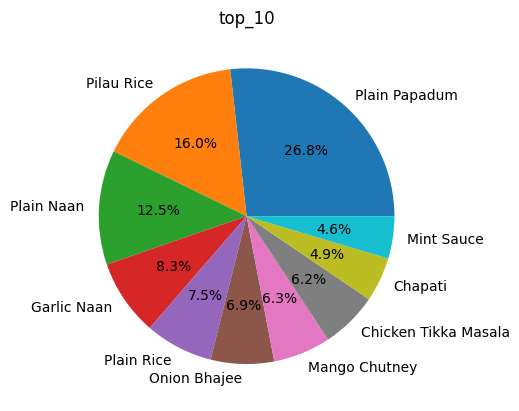

In [79]:
top_10_products = df.groupby("product_name")["quantity"].sum().nlargest(10)
fig, ax = plt.subplots()
ax.pie(top_10_products, labels=top_10_products.index, autopct='%.1f%%')
plt.title("top_10")
plt.show()

# Task 2
Calculate `Item Price` (Product Price * Quantity) for each Order Item in dataframe.
And Make the same Top 10 pie chart, but this time by `Item Price`. So this chart should describe not the most popular products by quantity, but which products (top 10) make the most money for restaurant. It should be also with percentage.

In [96]:
df["item_price"] = df["quantity"] * df["price"]
df

,quantity,product_name,price,total_price,item_price
date,,,,,
2019-08-03 20:25:00,2,Plain Papadum,0.80,1.60,1.60
2019-08-03 20:25:00,1,King Prawn Balti,12.95,12.95,12.95
2019-08-03 20:25:00,1,Garlic Naan,2.95,2.95,2.95
2019-08-03 20:25:00,1,Mushroom Rice,3.95,3.95,3.95
2019-08-03 20:25:00,1,Paneer Tikka Masala,8.95,8.95,8.95
...,...,...,...,...,...
2017-02-23 18:20:00,1,Lamb Shashlick Curry,12.95,12.95,12.95
2016-10-23 16:03:00,3,Tandoori King Prawn Garlic,12.95,38.85,38.85
2018-12-24 13:22:00,2,House Red wine 75cl,17.95,35.90,35.90


In [97]:
total_revenue = df.groupby("product_name")["item_price"].sum().nlargest(10)
total_revenue

product_name
Chicken Tikka Masala    22133.35
Pilau Rice              18782.65
Plain Naan              12955.80
Korma                   12261.50
Bombay Aloo             10894.45
Onion Bhajee            10858.55
Butter Chicken          10626.60
Garlic Naan              9788.10
Korma - Chicken          9764.45
Plain Rice               8743.80
Name: item_price, dtype: float64

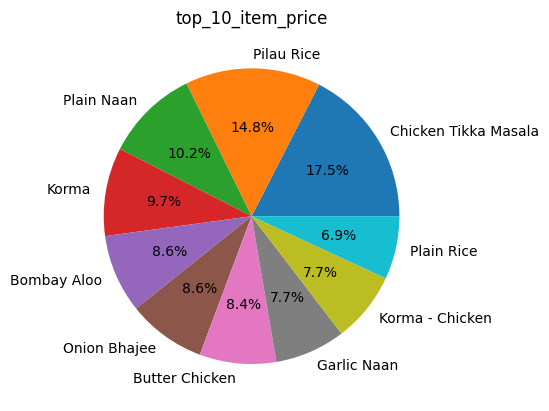

In [98]:
fig, ax = plt.subplots()
ax.pie(total_revenue, labels=total_revenue.index, autopct='%.1f%%')
plt.title("top_10_item_price")
plt.show()

# Task 3
Calculate `Order Hour` based on `Order Datetime`, which will tell about the specific our the order was created (from 0 to 23). Using `Order Hour` create a bar chart, which will tell the total restaurant income based on the hour order was created. So on x-axis - it will be values from 0 to 23 (hours), on y-axis - it will be the total sum of order prices, which were sold on that hour.

Example:

![bar chart](../demo/bar.png)

In [101]:
df["order_hour"] = df.index.hour
df

,quantity,product_name,price,total_price,item_price,order_hour
date,,,,,,
2019-08-03 20:25:00,2,Plain Papadum,0.80,1.60,1.60,20
2019-08-03 20:25:00,1,King Prawn Balti,12.95,12.95,12.95,20
2019-08-03 20:25:00,1,Garlic Naan,2.95,2.95,2.95,20
2019-08-03 20:25:00,1,Mushroom Rice,3.95,3.95,3.95,20
2019-08-03 20:25:00,1,Paneer Tikka Masala,8.95,8.95,8.95,20
...,...,...,...,...,...,...
2017-02-23 18:20:00,1,Lamb Shashlick Curry,12.95,12.95,12.95,18
2016-10-23 16:03:00,3,Tandoori King Prawn Garlic,12.95,38.85,38.85,16
2018-12-24 13:22:00,2,House Red wine 75cl,17.95,35.90,35.90,13


In [109]:
total_restaurant_income = df.groupby("order_hour")["item_price"].sum()
total_restaurant_income


order_hour
0        177.95
1         54.65
2        199.25
3          8.90
4         63.45
5         57.40
6        121.60
8        447.70
9        570.60
10      1250.35
11      3807.05
12     10565.85
13      8282.65
14      3343.55
15      3781.70
16     15634.75
17     72110.20
18    132462.50
19    109045.05
20     50218.25
21     21480.30
22     11001.50
23       373.25
Name: item_price, dtype: float64

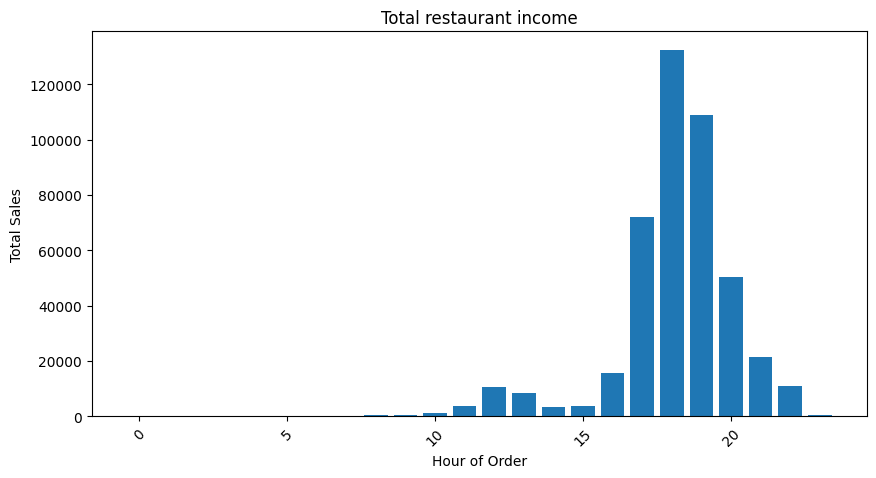

In [108]:
plt.figure(figsize=(10, 5))

plt.bar(total_restaurant_income.index, total_restaurant_income.values)
plt.xlabel('Hour of Order')
plt.ylabel('Total Sales')
plt.title("Total restaurant income")
plt.xticks(rotation=45)
plt.show()

# Task 4
Make similar bar chart, but right now with `Order Day Of The Week` (from Monday to Sunday), and also analyze total restaurant income by each day of the week.

In [110]:
df


,quantity,product_name,price,total_price,item_price,order_hour
date,,,,,,
2019-08-03 20:25:00,2,Plain Papadum,0.80,1.60,1.60,20
2019-08-03 20:25:00,1,King Prawn Balti,12.95,12.95,12.95,20
2019-08-03 20:25:00,1,Garlic Naan,2.95,2.95,2.95,20
2019-08-03 20:25:00,1,Mushroom Rice,3.95,3.95,3.95,20
2019-08-03 20:25:00,1,Paneer Tikka Masala,8.95,8.95,8.95,20
...,...,...,...,...,...,...
2017-02-23 18:20:00,1,Lamb Shashlick Curry,12.95,12.95,12.95,18
2016-10-23 16:03:00,3,Tandoori King Prawn Garlic,12.95,38.85,38.85,16
2018-12-24 13:22:00,2,House Red wine 75cl,17.95,35.90,35.90,13


In [117]:
df["order_day_of_the_week"] = df.index.weekday
df["order_day_name"] = df.index.strftime('%A')
df

,quantity,product_name,price,total_price,item_price,order_hour,order_day,order_day_of_the_week,order_day_name
date,,,,,,,,,
2019-08-03 20:25:00,2,Plain Papadum,0.80,1.60,1.60,20,3,5,Saturday
2019-08-03 20:25:00,1,King Prawn Balti,12.95,12.95,12.95,20,3,5,Saturday
2019-08-03 20:25:00,1,Garlic Naan,2.95,2.95,2.95,20,3,5,Saturday
2019-08-03 20:25:00,1,Mushroom Rice,3.95,3.95,3.95,20,3,5,Saturday
2019-08-03 20:25:00,1,Paneer Tikka Masala,8.95,8.95,8.95,20,3,5,Saturday
...,...,...,...,...,...,...,...,...,...
2017-02-23 18:20:00,1,Lamb Shashlick Curry,12.95,12.95,12.95,18,23,3,Thursday
2016-10-23 16:03:00,3,Tandoori King Prawn Garlic,12.95,38.85,38.85,16,23,6,Sunday
2018-12-24 13:22:00,2,House Red wine 75cl,17.95,35.90,35.90,13,24,0,Monday


In [118]:
total_by_the_day = df.groupby("order_day_name")["total_price"].sum()
total_by_the_day

order_day_name
Friday       100339.15
Monday        40008.30
Saturday     112191.65
Sunday        67105.95
Thursday      46021.55
Tuesday       38145.65
Wednesday     41246.20
Name: total_price, dtype: float64

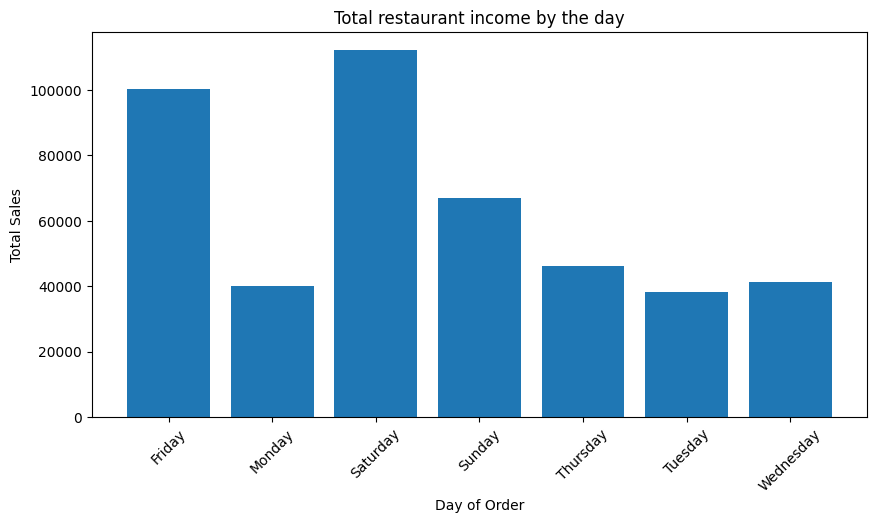

In [119]:
plt.figure(figsize=(10, 5))

plt.bar(total_by_the_day.index, total_by_the_day.values)
plt.xlabel('Day of Order')
plt.ylabel('Total Sales')
plt.title("Total restaurant income by the day")
plt.xticks(rotation=45)
plt.show()